In [1]:
%pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve,
                             precision_recall_curve, f1_score)

# Load processed data
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').values.ravel()
y_test  = pd.read_csv('data/y_test.csv').values.ravel()
feature_names = pickle.load(open('models/feature_names.pkl', 'rb'))

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate : {y_test.mean()*100:.1f}%")

Train: (8260, 46) | Test: (1407, 46)
Train churn rate: 50.0%
Test churn rate : 26.6%


In [2]:
# --- Model 1: Logistic Regression (baseline) ---
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# --- Model 3: XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

print("✓ All 3 models trained")

✓ All 3 models trained


In [3]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    auc   = roc_auc_score(y_test, y_prob)
    f1    = f1_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    recall    = report['1']['recall']
    precision = report['1']['precision']
    
    return {
        'Model'    : name,
        'AUC-ROC'  : round(auc, 4),
        'F1 Score' : round(f1, 4),
        'Recall'   : round(recall, 4),
        'Precision': round(precision, 4)
    }

results = [
    evaluate_model('Logistic Regression', lr,  X_test, y_test),
    evaluate_model('Random Forest',        rf,  X_test, y_test),
    evaluate_model('XGBoost',              xgb, X_test, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     AUC-ROC  F1 Score  Recall  Precision
Model                                                    
Logistic Regression   0.8403    0.6252  0.6578     0.5956
Random Forest         0.8338    0.6080  0.6738     0.5538
XGBoost               0.8277    0.5775  0.5775     0.5775


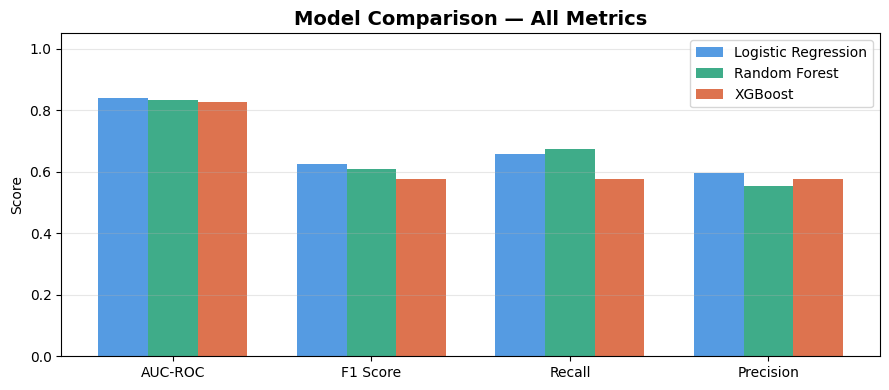

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results_df.columns))
width = 0.25
colors = ['#378ADD', '#1D9E75', '#D85A30']

for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, 
                  label=model_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/07_model_comparison.png', dpi=150)
plt.show()

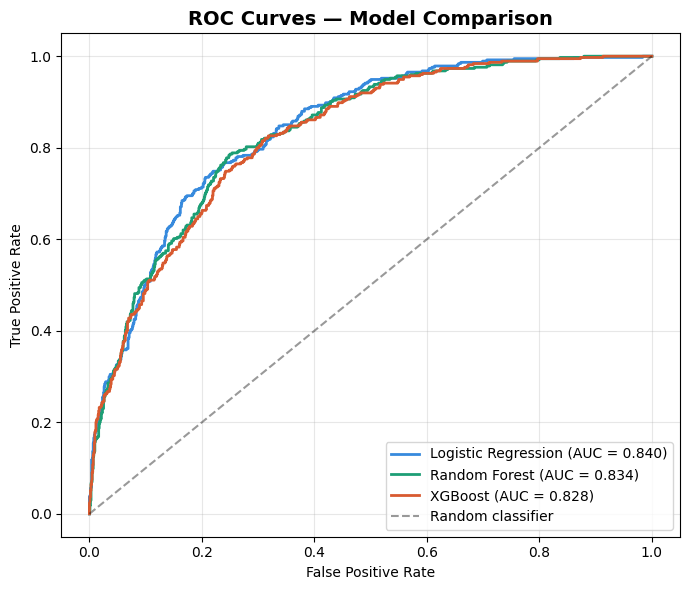

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, model, color in [
    ('Logistic Regression', lr,  '#378ADD'),
    ('Random Forest',        rf,  '#1D9E75'),
    ('XGBoost',              xgb, '#D85A30')
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', 
            color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/08_roc_curves.png', dpi=150)
plt.show()

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'n_estimators'     : [200, 300],
    'subsample'        : [0.7, 0.8],
    'colsample_bytree' : [0.7, 0.8]
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best AUC-ROC : {grid_search.best_score_:.4f}")
print(f"Best params  : {grid_search.best_params_}")

xgb_tuned = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best AUC-ROC : 0.9407
Best params  : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


 Threshold  Recall  Precision    F1
      0.10   0.909      0.417 0.571
      0.15   0.872      0.447 0.591
      0.20   0.802      0.463 0.587
      0.25   0.773      0.487 0.597
      0.30   0.725      0.505 0.595
      0.35   0.682      0.528 0.595
      0.40   0.636      0.538 0.583
      0.45   0.591      0.558 0.574
      0.50   0.559      0.582 0.570
      0.55   0.519      0.601 0.557
      0.60   0.500      0.628 0.557
      0.65   0.479      0.646 0.550


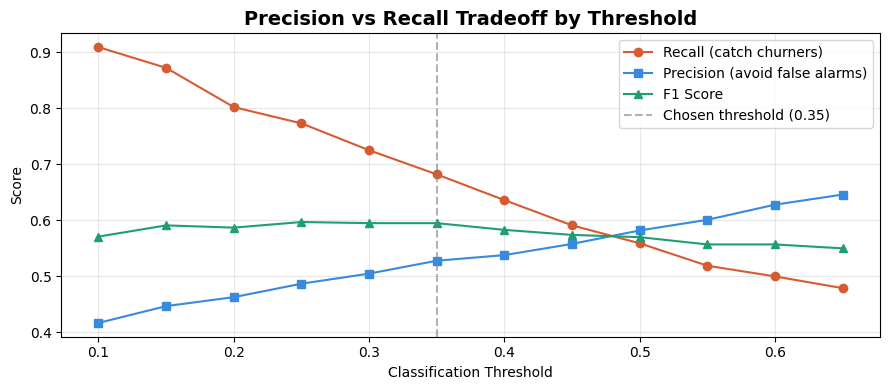

In [7]:
y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 0.7, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_tuned >= thresh).astype(int)
    report = classification_report(y_test, y_pred_thresh, 
                                   output_dict=True, zero_division=0)
    threshold_results.append({
        'Threshold' : round(thresh, 2),
        'Recall'    : round(report['1']['recall'], 3),
        'Precision' : round(report['1']['precision'], 3),
        'F1'        : round(report['1']['f1-score'], 3)
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

# Plot threshold tradeoff
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],
        marker='o', label='Recall (catch churners)', color='#D85A30')
ax.plot(thresh_df['Threshold'], thresh_df['Precision'],
        marker='s', label='Precision (avoid false alarms)', color='#378ADD')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],
        marker='^', label='F1 Score', color='#1D9E75')
ax.axvline(x=0.35, color='gray', linestyle='--', alpha=0.6, label='Chosen threshold (0.35)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall Tradeoff by Threshold', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/09_threshold_tradeoff.png', dpi=150)
plt.show()

In [8]:
# Apply chosen threshold
THRESHOLD = 0.35
y_pred_final = (y_prob_tuned >= THRESHOLD).astype(int)

print("\nFINAL MODEL PERFORMANCE (threshold = 0.35)")
print("=" * 45)
print(classification_report(y_test, y_pred_final, 
                             target_names=['Stayed', 'Churned']))


FINAL MODEL PERFORMANCE (threshold = 0.35)
              precision    recall  f1-score   support

      Stayed       0.87      0.78      0.82      1033
     Churned       0.53      0.68      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



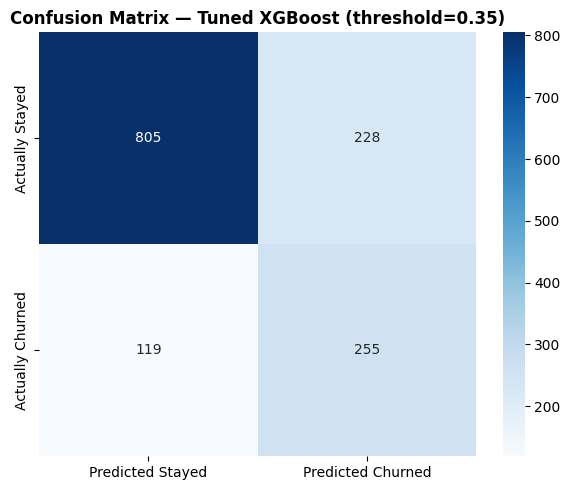


True Positives  (caught churners)     : 255
False Negatives (missed churners)     : 119
False Positives (wrongly flagged)     : 228
True Negatives  (correctly kept)      : 805

Of all actual churners, we caught     : 68.2%
Of all flagged customers, truly risky : 52.8%


In [9]:
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actually Stayed', 'Actually Churned'])
ax.set_title('Confusion Matrix — Tuned XGBoost (threshold=0.35)', 
             fontweight='bold')
plt.tight_layout()
plt.savefig('charts/10_confusion_matrix.png', dpi=150)
plt.show()

# Translate to plain English
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (caught churners)     : {tp}")
print(f"False Negatives (missed churners)     : {fn}")
print(f"False Positives (wrongly flagged)     : {fp}")
print(f"True Negatives  (correctly kept)      : {tn}")
print(f"\nOf all actual churners, we caught     : {tp/(tp+fn)*100:.1f}%")
print(f"Of all flagged customers, truly risky : {tp/(tp+fp)*100:.1f}%")

In [11]:
import sys
!{sys.executable} -m pip install shap

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.4/562.4 kB 7.2 MB/s  0:00:00m ? eta -:--:--
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 54.0 MB/s  0:00:006.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 61.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]━━━━━━ 5/6 [shap] [numba]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


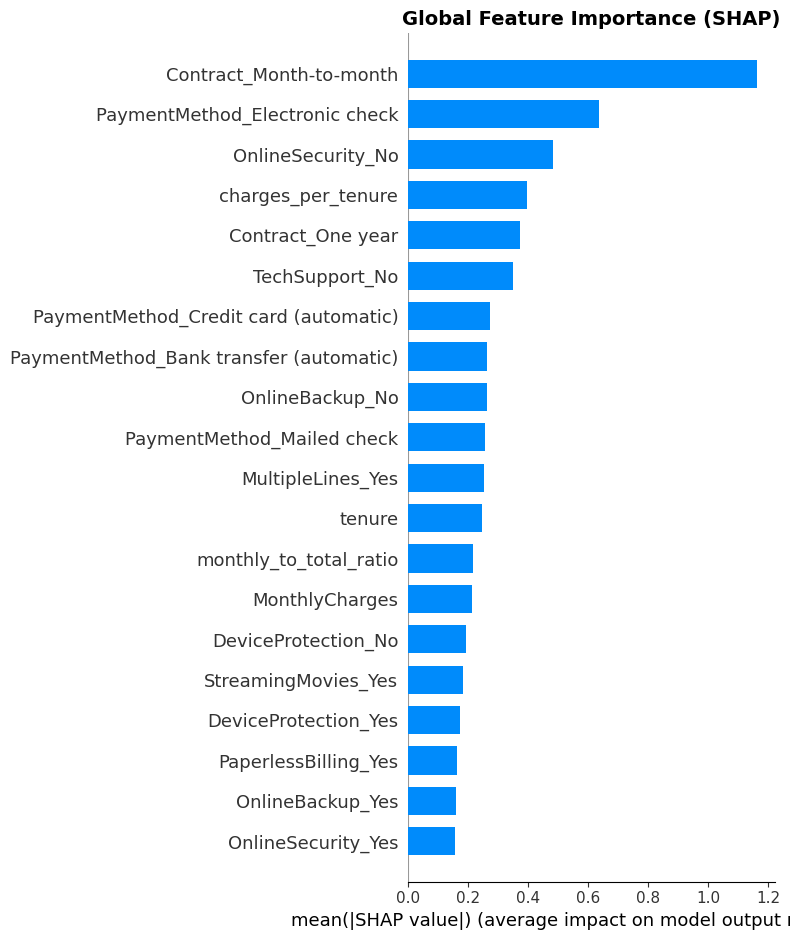

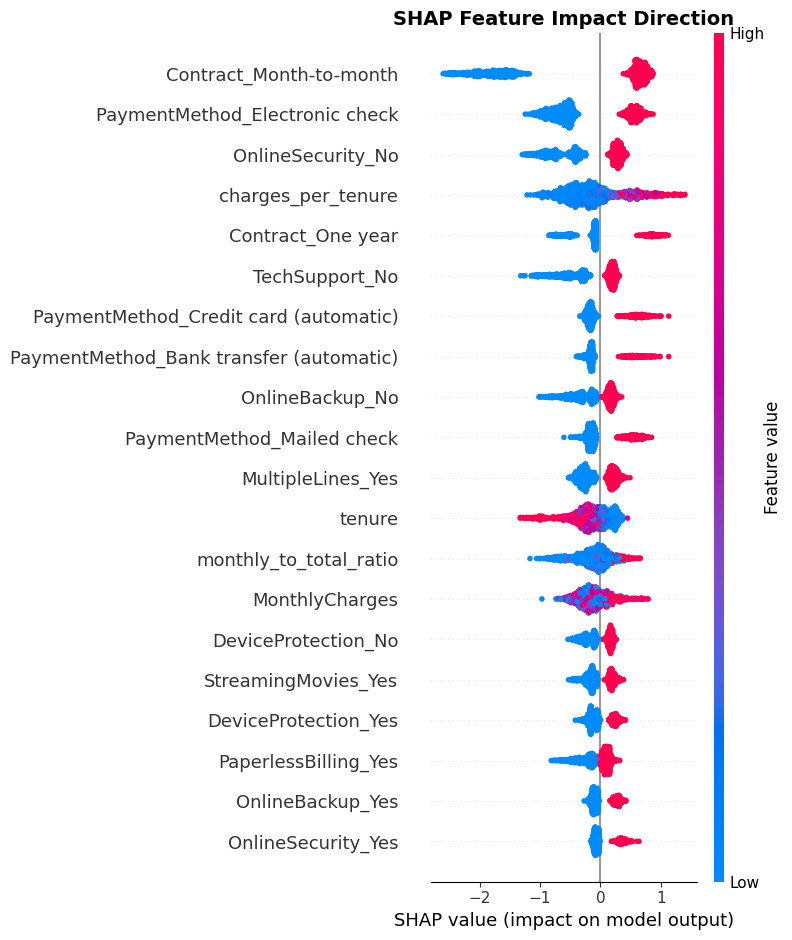

In [12]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# --- Global feature importance ---
fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=False)
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/11_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Beeswarm plot (shows direction of impact) ---
fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/12_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

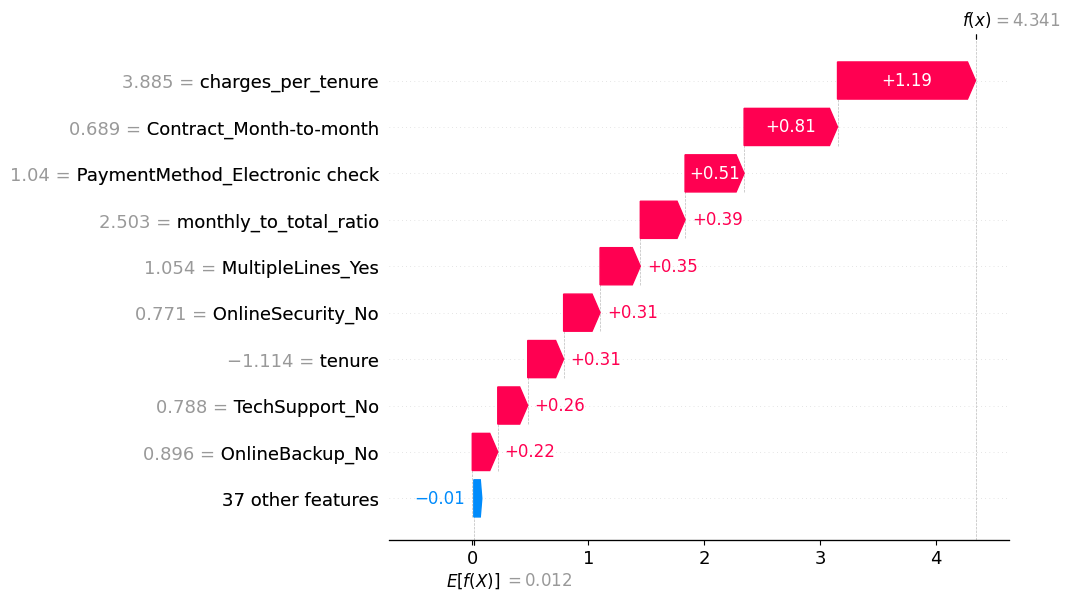

<Figure size 640x480 with 0 Axes>


Highest risk customer churn probability: 98.7%


In [13]:
# --- Individual customer explanation ---
# Pick the highest-risk customer and explain exactly why
highest_risk_idx = y_prob_tuned.argmax()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[highest_risk_idx],
        feature_names=feature_names
    )
)
plt.savefig('charts/13_shap_individual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nHighest risk customer churn probability: {y_prob_tuned[highest_risk_idx]*100:.1f}%")

In [14]:
pickle.dump(xgb_tuned,    open('models/xgb_tuned.pkl', 'wb'))
pickle.dump(THRESHOLD,    open('models/threshold.pkl', 'wb'))

print("✓ Model saved to models/xgb_tuned.pkl")
print("✓ Threshold saved to models/threshold.pkl")
print("\nFinal model summary:")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"  Recall    : {y_pred_final[y_test==1].mean()*100:.1f}% of churners caught")
print(f"  Threshold : {THRESHOLD}")

✓ Model saved to models/xgb_tuned.pkl
✓ Threshold saved to models/threshold.pkl

Final model summary:
  AUC-ROC   : 0.8216
  Recall    : 68.2% of churners caught
  Threshold : 0.35
